## Cross-dataset GNN Training: FIREbox and TNG

This notebook trains a GraphSAGE model on FIREbox and TNG datasets using the shared data-processing pipeline, and compares **in-dataset** and **cross-dataset** performance:

- Train on FIREbox, test on FIREbox
- Train on TNG, test on TNG
- Train on FIREbox, test on TNG
- Train on TNG, test on FIREbox

It reuses the processing and training utilities from `scripts/process_data.py`, `scripts/process_tng_data.py`, `scripts/model.py`, and `scripts/train.py`.


In [1]:
# Setup python path to import from the project scripts
import os
import sys

# Assuming this notebook lives in the `notebooks/` directory
project_root = os.path.dirname(os.getcwd())
scripts_dir = os.path.join(project_root, "scripts")

if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)

print("Project root:", project_root)
print("Scripts dir:", scripts_dir)


Project root: d:\Minerva\Senior Year\Capstone\DM_FIREbox_fresh
Scripts dir: d:\Minerva\Senior Year\Capstone\DM_FIREbox_fresh\scripts


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

from model import GraphSAGENet
from process_data import DataProcessor
from process_tng_data import TNGDataProcessor
from train import train_epoch_full_graph, evaluate_full_graph

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data file paths relative to project root
firebox_path = os.path.join(project_root, "data", "firebox_data", "FIREbox_z=0.txt")
tng_path = os.path.join(project_root, "data", "tng-data", "TNG300-1-subhalos_99.parquet")

print("FIREbox path:", firebox_path)
print("TNG path:", tng_path)


Using device: cpu
FIREbox path: d:\Minerva\Senior Year\Capstone\DM_FIREbox_fresh\data\firebox_data\FIREbox_z=0.txt
TNG path: d:\Minerva\Senior Year\Capstone\DM_FIREbox_fresh\data\tng-data\TNG300-1-subhalos_99.parquet


In [3]:
def build_dataset(dataset: str, path: str):
    """Build a PyG Data object for the given dataset.

    Parameters
    ----------
    dataset : {"firebox", "tng"}
    path : str
        File path to the underlying data file.
    """
    if dataset == "firebox":
        processor = DataProcessor(file_path=path)
        # Use stellar mass feature to match TNG dimensionality
        processor.create_graph_data(include_Rhalo=False)
    elif dataset == "tng":
        processor = TNGDataProcessor(file_path=path)
        processor.create_graph_data(r=0.8)  # Use r=0.8 for TNG
    else:
        raise ValueError(f"Unknown dataset: {dataset}")

    return processor.data


def run_experiment(train_dataset: str,
                   test_dataset: str,
                   firebox_data,
                   tng_data,
                   num_layers: int = 2,
                   hidden_channels: int = 64,
                   mlp_hidden: int = 128,
                   learning_rate: float = 1e-3,
                   num_epochs: int = 300):
    """Train on one dataset and evaluate on another.

    Parameters
    ----------
    train_dataset : str
        Dataset to train on ("firebox" or "tng")
    test_dataset : str
        Dataset to test on ("firebox" or "tng")
    firebox_data : torch_geometric.data.Data
        Pre-built FIREbox graph data
    tng_data : torch_geometric.data.Data
        Pre-built TNG graph data
    
    Returns a dict with final RMSE/MAE and history.
    """
    # Use pre-built datasets
    if train_dataset == "firebox":
        train_data = firebox_data
    else:
        train_data = tng_data

    if test_dataset == "firebox":
        test_data = firebox_data
    else:
        test_data = tng_data

    # Sanity check on feature dimensions
    if train_data.x.size(1) != test_data.x.size(1):
        raise ValueError(
            f"Feature dimension mismatch: train has {train_data.x.size(1)}, "
            f"test has {test_data.x.size(1)}"
        )

    print(f"\n=== Experiment: train on {train_dataset}, test on {test_dataset} ===")
    print(f"Train nodes: {train_data.train_mask.sum().item()}, Test nodes (train graph): {train_data.test_mask.sum().item()}")
    print(f"Test graph nodes: {test_data.test_mask.sum().item()} (using its test_mask)")

    # Initialize model
    model = GraphSAGENet(
        in_channels=train_data.x.size(1),
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        mlp_hidden=mlp_hidden,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = []
    best_rmse = float("inf")
    best_model_state = None

    for epoch in range(num_epochs):
        # Train on train_data using its train_mask
        train_loss = train_epoch_full_graph(model, optimizer, train_data, device)

        # Evaluate on test_data using its val_mask (early stopping; test_mask untouched)
        rmse, mae, r2, _, _ = evaluate_full_graph(model, test_data, device, mask_name='val_mask')

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "rmse": float(rmse),
            "mae": float(mae),
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_rmse={rmse:.4f} | val_r2={r2:.4f}")

    print(f"Best val RMSE over training: {best_rmse:.4f}")

    # Load best model state for predictions
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "train_dataset": train_dataset,
        "test_dataset": test_dataset,
        "history": history,
        "best_rmse": float(best_rmse),
        "final_rmse": float(history[-1]["rmse"]),
        "final_mae": float(history[-1]["mae"]),
        "model": model,
        "test_data": test_data,
    }

In [4]:
# Build datasets once and reuse for all experiments
print("Building FIREbox dataset...")
firebox_data = build_dataset("firebox", firebox_path)
print(f"FIREbox: {firebox_data.x.size(0)} nodes, {firebox_data.edge_index.size(1)} edges")

print("\nBuilding TNG dataset...")
tng_data = build_dataset("tng", tng_path)
print(f"TNG: {tng_data.x.size(0)} nodes, {tng_data.edge_index.size(1)} edges")

# Run the four train/test combinations
num_layers = 2
hidden_channels = 64
mlp_hidden = 128
learning_rate = 1e-3
num_epochs = 300

experiments = [
    ("firebox", "firebox"),
    ("tng", "tng"),
    ("firebox", "tng"),
    ("tng", "firebox"),
]

results = []
for train_ds, test_ds in experiments:
    res = run_experiment(
        train_dataset=train_ds,
        test_dataset=test_ds,
        firebox_data=firebox_data,
        tng_data=tng_data,
        num_layers=num_layers,
        hidden_channels=hidden_channels,
        mlp_hidden=mlp_hidden,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
    )
    results.append(res)

Building FIREbox dataset...
FIREbox: 2031 nodes, 345852 edges

Building TNG dataset...
TNG: 6436 nodes, 1908100 edges

=== Experiment: train on firebox, test on firebox ===
Train nodes: 1624, Test nodes (train graph): 204
Test graph nodes: 204 (using its test_mask)
Epoch 000 | train_loss=100.4914 | val_rmse=9.9241 | val_r2=-330.8484
Epoch 010 | train_loss=77.3482 | val_rmse=8.6207 | val_r2=-249.4054
Epoch 020 | train_loss=48.9697 | val_rmse=6.6718 | val_r2=-148.9827
Epoch 030 | train_loss=17.9242 | val_rmse=3.7529 | val_r2=-46.4555
Epoch 040 | train_loss=1.4916 | val_rmse=0.5765 | val_r2=-0.1197
Epoch 050 | train_loss=2.7512 | val_rmse=1.4780 | val_r2=-6.3601
Epoch 060 | train_loss=1.2839 | val_rmse=0.6680 | val_r2=-0.5034
Epoch 070 | train_loss=1.2008 | val_rmse=0.5956 | val_r2=-0.1955
Epoch 080 | train_loss=1.0394 | val_rmse=0.5178 | val_r2=0.0965
Epoch 090 | train_loss=0.9961 | val_rmse=0.4767 | val_r2=0.2345
Epoch 100 | train_loss=0.9853 | val_rmse=0.4615 | val_r2=0.2824
Epoch 110 

In [5]:
# Summarize results in a table
summary_rows = []
for res in results:
    summary_rows.append({
        "train_dataset": res["train_dataset"],
        "test_dataset": res["test_dataset"],
        "best_rmse": res["best_rmse"],
        "final_rmse": res["final_rmse"],
        "final_mae": res["final_mae"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values(by=["train_dataset", "test_dataset"], inplace=True)
summary_df.reset_index(drop=True, inplace=True)
summary_df


,train_dataset,test_dataset,best_rmse,final_rmse,final_mae
0,firebox,firebox,0.257736,0.257736,0.171376
1,firebox,tng,0.725685,1.777100,1.754641
2,tng,firebox,0.551939,1.754654,1.732374
3,tng,tng,0.272844,0.272917,0.190754


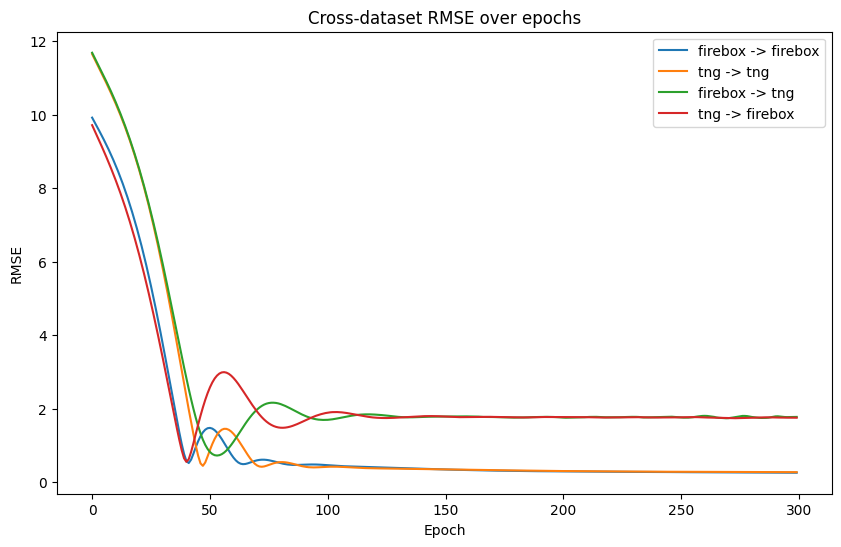

In [6]:
# (Optional) Plot RMSE curves for each experiment (clean labels)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for res in results:
    hist = res["history"]
    epochs = [h["epoch"] for h in hist]
    rmses = [h["rmse"] for h in hist]
    label = f"{res['train_dataset']} -> {res['test_dataset']}"
    plt.plot(epochs, rmses, label=label)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Cross-dataset RMSE over epochs")
plt.legend()
plt.show()


<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_21768\185638611.py:31: SyntaxWarning: invalid escape sequence '\l'
  axes[idx].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_21768\185638611.py:32: SyntaxWarning: invalid escape sequence '\l'
  axes[idx].set_ylabel('Pred $\log M_{halo}$')


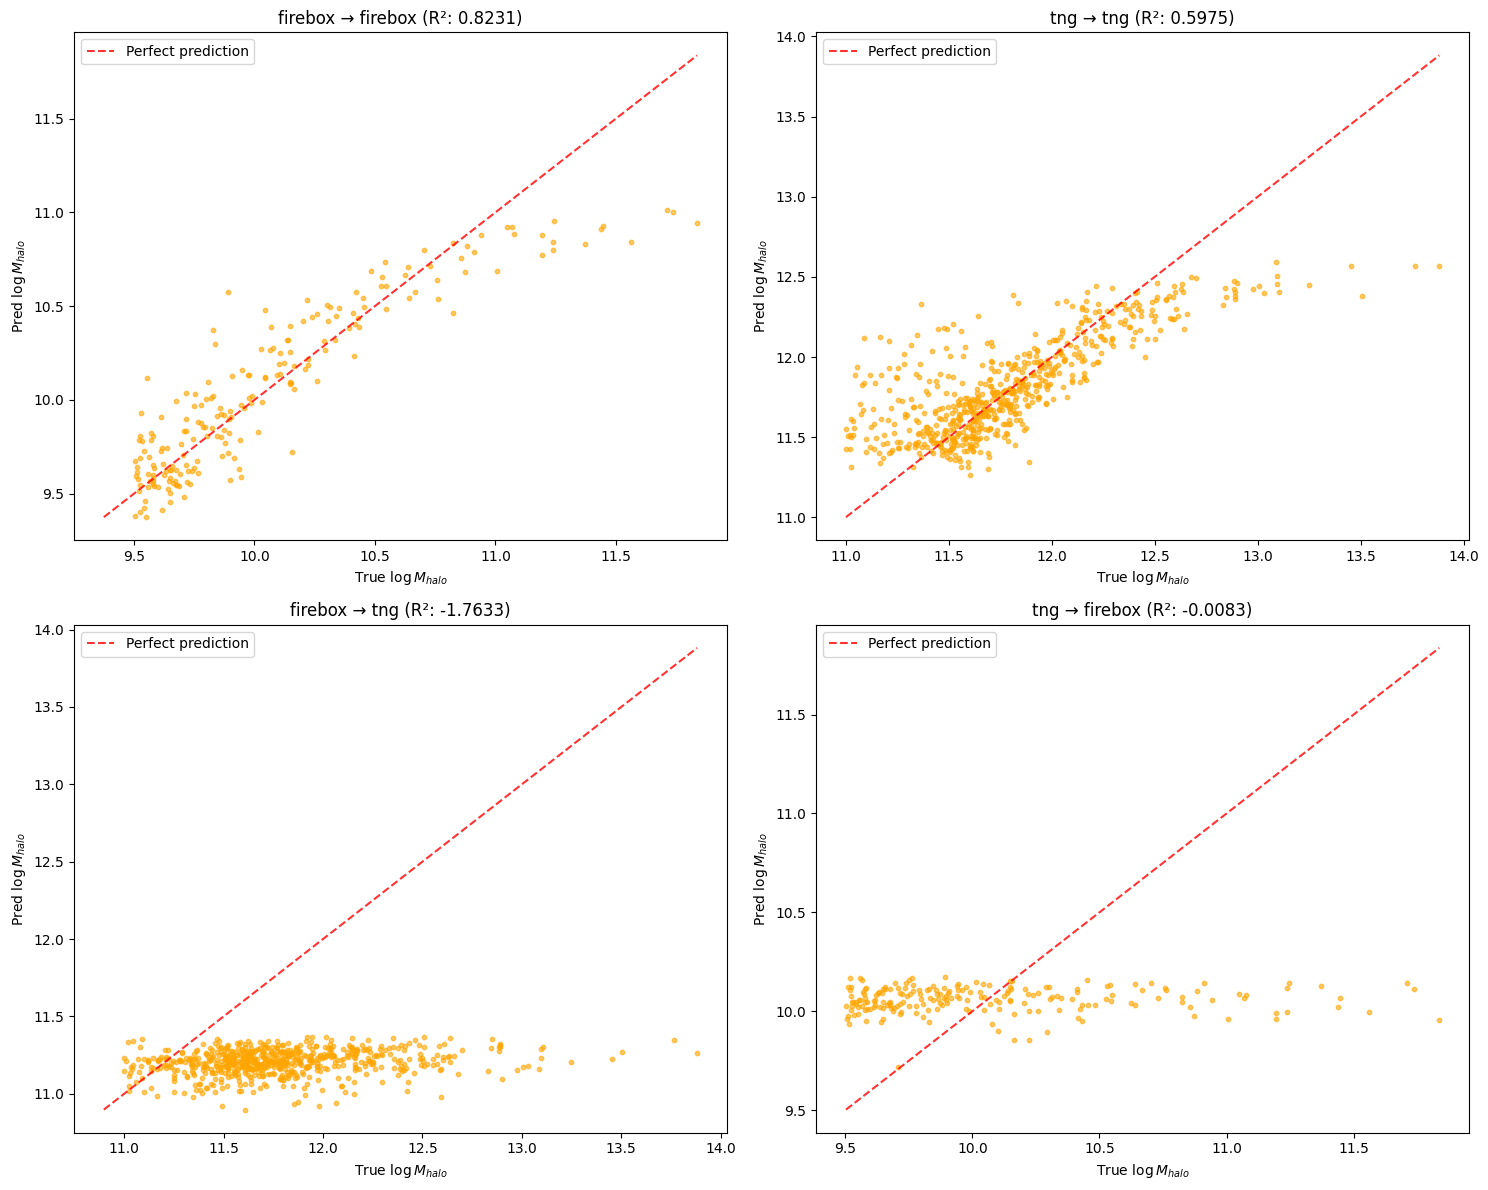


R² Scores (test set):
firebox -> firebox: R² = 0.8231
tng -> tng: R² = 0.5975
firebox -> tng: R² = -1.7633
tng -> firebox: R² = -0.0083


In [7]:
# Visualize predictions for all four experiments
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Get predictions for test set only for each experiment
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, res in enumerate(results):
    model = res['model']
    test_data = res['test_data']
    train_ds = res['train_dataset']
    test_ds = res['test_dataset']
    
    # Get all predictions and filter by test_mask
    all_pred = model.predict(test_data, device)
    all_true = test_data.y.view(-1).cpu()
    test_mask = test_data.test_mask.cpu()
    
    pred = all_pred[test_mask]
    true = all_true[test_mask]
    
    # Calculate R² for test set
    r2 = r2_score(true.numpy(), pred.numpy())
    
    # Create scatter plot
    axes[idx].scatter(true, pred, alpha=0.6, s=10, color='orange')
    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect prediction')
    axes[idx].set_xlabel('True $\log M_{halo}$')
    axes[idx].set_ylabel('Pred $\log M_{halo}$')
    axes[idx].set_title(f'{train_ds} → {test_ds} (R²: {r2:.4f})')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../paper/cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

# Print R² scores
print("\nR² Scores (test set):")
for res in results:
    train_ds = res['train_dataset']
    test_ds = res['test_dataset']
    model = res['model']
    test_data = res['test_data']
    
    all_pred = model.predict(test_data, device)
    all_true = test_data.y.view(-1).cpu()
    test_mask = test_data.test_mask.cpu()
    
    pred = all_pred[test_mask]
    true = all_true[test_mask]
    r2 = r2_score(true.numpy(), pred.numpy())
    
    print(f"{train_ds} -> {test_ds}: R² = {r2:.4f}")